In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.calibration import calibration_curve

PROJECT_ROOT = Path.cwd().parent.parent
MODEL_RUNS_DIR = PROJECT_ROOT / "results" / "model_runs"

# ------------------------------------------------------------
# Choose the RF OOF run used for model comparison
# ------------------------------------------------------------
rf_oof_run_dir = MODEL_RUNS_DIR / "random_forest_overnight_2026_03_20_neg_log_loss_20260320_031327"

# ------------------------------------------------------------
# Automatically pick the latest final RF run
# ------------------------------------------------------------
rf_final_run_dir = sorted(MODEL_RUNS_DIR.glob("random_forest_final_*"))[-1]

print("RF OOF run dir:", rf_oof_run_dir)
print("RF final run dir:", rf_final_run_dir)

# ------------------------------------------------------------
# Load predictions and metrics
# ------------------------------------------------------------
rf_oof_predictions = pd.read_csv(rf_oof_run_dir / "oof_predictions.csv")
rf_oof_metrics = pd.read_csv(rf_oof_run_dir / "summary_metrics.csv")

rf_test_predictions = pd.read_csv(rf_final_run_dir / "test_predictions.csv")
rf_test_metrics = pd.read_csv(rf_final_run_dir / "test_metrics.csv")

print(rf_oof_predictions.columns.tolist())
print(rf_test_predictions.columns.tolist())

RF OOF run dir: c:\Users\john\Desktop\spring-2026-radon-risk-mapping\results\model_runs\random_forest_overnight_2026_03_20_neg_log_loss_20260320_031327
RF final run dir: c:\Users\john\Desktop\spring-2026-radon-risk-mapping\results\model_runs\random_forest_final_final_refit_test_eval_2026_03_20_20260320_135505
['model_name', 'run_id', 'row_index', 'cv_fold', 'y_true', 'oof_prob', 'oof_pred_at_threshold', 'FSA', 'concentration']
['model_name', 'run_id', 'row_index', 'y_true', 'test_prob', 'test_pred_at_0p10', 'test_pred_at_0p15', 'FSA', 'concentration']


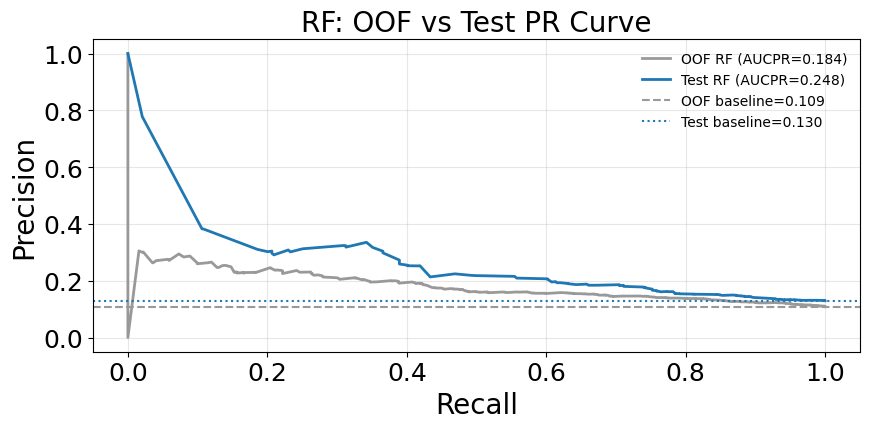

In [5]:
# ------------------------------------------------------------
# OOF RF PR curve
# ------------------------------------------------------------
y_oof = rf_oof_predictions["y_true"].values
p_oof = rf_oof_predictions["oof_prob"].values

precision_oof, recall_oof, _ = precision_recall_curve(y_oof, p_oof)
aucpr_oof = average_precision_score(y_oof, p_oof)
baseline_oof = y_oof.mean()

# ------------------------------------------------------------
# Final test RF PR curve
# ------------------------------------------------------------
y_test = rf_test_predictions["y_true"].values
p_test = rf_test_predictions["test_prob"].values

precision_test, recall_test, _ = precision_recall_curve(y_test, p_test)
aucpr_test = average_precision_score(y_test, p_test)
baseline_test = y_test.mean()

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plot_fontsize = 20
oof_color = "0.6"
final_color = "tab:blue"

plt.figure(figsize=(8.8, 4.4))

plt.plot(
    recall_oof,
    precision_oof,
    color=oof_color,
    linewidth=2,
    label=f"OOF RF (AUCPR={aucpr_oof:.3f})"
)

plt.plot(
    recall_test,
    precision_test,
    color=final_color,
    linewidth=2,
    label=f"Test RF (AUCPR={aucpr_test:.3f})"
)

plt.axhline(
    baseline_oof,
    color=oof_color,
    linestyle="--",
    linewidth=1.5,
    label=f"OOF baseline={baseline_oof:.3f}"
)

plt.axhline(
    baseline_test,
    color=final_color,
    linestyle=":",
    linewidth=1.5,
    label=f"Test baseline={baseline_test:.3f}"
)

plt.xlabel("Recall", fontsize=plot_fontsize)
plt.ylabel("Precision", fontsize=plot_fontsize)
plt.title("RF: OOF vs Test PR Curve", fontsize=plot_fontsize)
plt.xticks(fontsize=plot_fontsize - 2)
plt.yticks(fontsize=plot_fontsize - 2)
plt.legend(fontsize=10, loc="best", frameon=False)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    rf_final_run_dir / "rf_pr_curve_oof_vs_test_overlay.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

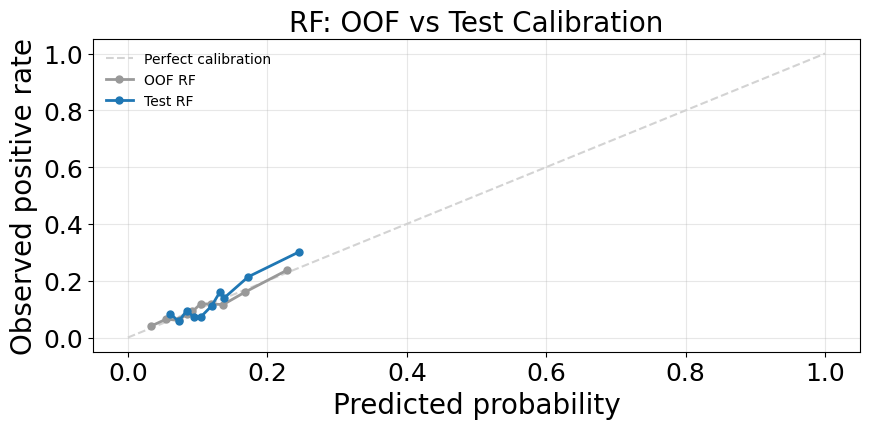

In [ ]:
N_CALIBRATION_BINS = 10

# ------------------------------------------------------------
# OOF calibration
# ------------------------------------------------------------
frac_pos_oof, mean_pred_oof = calibration_curve(
    y_oof,
    p_oof,
    n_bins=N_CALIBRATION_BINS,
    strategy="quantile",
)

# ------------------------------------------------------------
# Test calibration
# ------------------------------------------------------------
frac_pos_test, mean_pred_test = calibration_curve(
    y_test,
    p_test,
    n_bins=N_CALIBRATION_BINS,
    strategy="quantile",
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plot_fontsize = 20
oof_color = "0.6"
final_color = "tab:blue"

plt.figure(figsize=(8.8, 4.4))
plt.plot(
    [0, 1],
    [0, 1],
    color="lightgrey",
    linestyle="--",
    linewidth=1.5,
    label="Perfect calibration"
)

plt.plot(
    mean_pred_oof,
    frac_pos_oof,
    marker="o",
    color=oof_color,
    linewidth=2,
    markersize=5,
    label="OOF RF"
)

plt.plot(
    mean_pred_test,
    frac_pos_test,
    marker="o",
    color=final_color,
    linewidth=2,
    markersize=5,
    label="Test RF"
)

plt.xlim(0.0, 0.35)
plt.ylim(0.0, 0.35)

plt.xlabel("Predicted probability", fontsize=plot_fontsize)
plt.ylabel("Observed positive rate", fontsize=plot_fontsize)
plt.title("RF: OOF vs Test Calibration", fontsize=plot_fontsize)
plt.xticks(fontsize=plot_fontsize - 2)
plt.yticks(fontsize=plot_fontsize - 2)
plt.legend(fontsize=10, loc="best", frameon=False)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    rf_final_run_dir / "rf_calibration_oof_vs_test_overlay.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
final_test_summary_table = pd.DataFrame([{
    "Model": "Random Forest",
    "ROC-AUC": rf_test_metrics.loc[0, "test_roc_auc"],
    "AUCPR": rf_test_metrics.loc[0, "test_aucpr"],
    "Log Loss": rf_test_metrics.loc[0, "test_log_loss"],
    "Brier": rf_test_metrics.loc[0, "test_brier"],
    "ECE": rf_test_metrics.loc[0, "test_ece"],
    "F1 @ 0.10": rf_test_metrics.loc[0, "test_f1_at_0p10"],
    "Recall @ 0.10": rf_test_metrics.loc[0, "test_recall_at_0p10"],
    "F1 @ 0.15": rf_test_metrics.loc[0, "test_f1_at_0p15"],
    "Recall @ 0.15": rf_test_metrics.loc[0, "test_recall_at_0p15"],
}]).round(3)

final_test_summary_table

,Model,ROC-AUC,AUCPR,Log Loss,Brier,ECE,F1 @ 0.10,Recall @ 0.10,F1 @ 0.15,Recall @ 0.15
0,Random Forest,0.661,0.248,0.366,0.108,0.008,0.272,0.752,0.317,0.389
